# ECGR 4106 Homework 3 - Question 2

## GRU Encoder-Decoder with Luong Attention: English to French

This notebook repeats the Question 1 English-to-French setup using the exact same saved split indices, then adds Luong dot-product attention to the decoder.

Required outputs saved by this notebook:
- `outputs/q2_attention_en_fr_loss.png`
- `outputs/q2_attention_en_fr_metrics.json`
- `outputs/q2_attention_en_fr_examples.csv`
- `outputs/q2_attention_map_1.png`
- `outputs/q2_attention_map_2.png`
- `outputs/q2_attention_en_fr.pt`

In [1]:
import sys
import subprocess
import importlib.util

required_packages = {
    "nltk": "nltk",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "numpy": "numpy",
    "tqdm": "tqdm",
}

for import_name, package in required_packages.items():
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

from pathlib import Path
import json
import csv
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
import json
import math
import os
import random
import unicodedata
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm import tqdm


PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"
SPECIAL_TOKENS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3


def set_seed(seed=4106):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def project_paths():
    """Find the dataset and make a local output folder in Colab or on a laptop."""
    here = Path.cwd()
    drive_root = Path("/content/drive/MyDrive")

    if Path("/content").exists() and not drive_root.exists():
        try:
            from google.colab import drive

            drive.mount("/content/drive")
        except Exception:
            pass

    candidates = [
        here / "vast_english_french.txt",
        here / "Problem" / "vast_english_french.txt",
        here.parent / "Problem" / "vast_english_french.txt",
        Path("/content/vast_english_french.txt"),
        Path("/content/Problem/vast_english_french.txt"),
        Path("/content/drive/MyDrive/vast_english_french.txt"),
    ]
    for candidate in candidates:
        if candidate.exists():
            dataset_path = candidate
            break
    else:
        search_roots = [here, Path("/content"), Path("/content/drive/MyDrive")]
        matches = []
        for root in search_roots:
            if root.exists():
                matches.extend(root.rglob("vast_english_french.txt"))
        if matches:
            dataset_path = matches[0]
        else:
            raise FileNotFoundError(
                "Could not find vast_english_french.txt. Upload it beside the notebook, "
                "put it in a Problem folder, or mount Drive and place it in MyDrive."
            )

    if "drive" in dataset_path.parts and dataset_path.parent.exists():
        work_dir = dataset_path.parent
    else:
        work_dir = here

    output_dir = work_dir / "outputs"
    output_dir.mkdir(parents=True, exist_ok=True)
    split_path = work_dir / "hw3_split_indices.json"
    return dataset_path, output_dir, split_path


def repair_mojibake(text):
    """Repair common UTF-8 text that was decoded as Latin-1, then normalize spaces."""
    if "Ã" in text or "Â" in text:
        try:
            text = text.encode("latin1").decode("utf-8")
        except UnicodeError:
            pass
    text = unicodedata.normalize("NFKC", text)
    return " ".join(text.strip().split())


def read_pairs(dataset_path):
    pairs = []
    with open(dataset_path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            eng, fra = line.split("\t", 1)
            pairs.append((repair_mojibake(eng), repair_mojibake(fra)))
    if not pairs:
        raise ValueError(f"No tab-separated sentence pairs found in {dataset_path}")
    return pairs


def get_or_create_split_indices(n_items, split_path, seed=4106, train_frac=0.80):
    if split_path.exists():
        with open(split_path, "r", encoding="utf-8") as f:
            payload = json.load(f)
        if payload.get("n_items") == n_items and payload.get("seed") == seed:
            return payload["train_indices"], payload["val_indices"]

    rng = random.Random(seed)
    indices = list(range(n_items))
    rng.shuffle(indices)
    train_size = int(train_frac * n_items)
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    payload = {
        "seed": seed,
        "train_fraction": train_frac,
        "n_items": n_items,
        "train_indices": train_indices,
        "val_indices": val_indices,
    }
    with open(split_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    return train_indices, val_indices


class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2idx = {tok: idx for idx, tok in enumerate(SPECIAL_TOKENS)}
        self.idx2word = {idx: tok for idx, tok in enumerate(SPECIAL_TOKENS)}
        self.word_counts = {}

    def add_sentence(self, sentence):
        for word in self.tokenize(sentence):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2idx:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
            self.word_counts[word] = 1
        else:
            self.word_counts[word] = self.word_counts.get(word, 0) + 1

    def tokenize(self, sentence):
        return sentence.strip().split()

    def encode(self, sentence):
        ids = [SOS_IDX]
        ids.extend(self.word2idx.get(tok, UNK_IDX) for tok in self.tokenize(sentence))
        ids.append(EOS_IDX)
        return ids

    def decode(self, ids):
        words = []
        for idx in ids:
            idx = int(idx)
            if idx == EOS_IDX:
                break
            if idx in (PAD_IDX, SOS_IDX):
                continue
            words.append(self.idx2word.get(idx, UNK_TOKEN))
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)


def build_vocabs(pairs, train_indices, source="en", target="fr"):
    src_vocab = Vocabulary(source)
    tgt_vocab = Vocabulary(target)
    for idx in train_indices:
        src, tgt = pairs[idx]
        src_vocab.add_sentence(src)
        tgt_vocab.add_sentence(tgt)
    return src_vocab, tgt_vocab


class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        return {
            "src_text": src,
            "tgt_text": tgt,
            "src_ids": torch.tensor(self.src_vocab.encode(src), dtype=torch.long),
            "tgt_ids": torch.tensor(self.tgt_vocab.encode(tgt), dtype=torch.long),
        }


def collate_batch(batch):
    src_ids = pad_sequence([item["src_ids"] for item in batch], batch_first=True, padding_value=PAD_IDX)
    tgt_ids = pad_sequence([item["tgt_ids"] for item in batch], batch_first=True, padding_value=PAD_IDX)
    src_lens = torch.tensor([len(item["src_ids"]) for item in batch], dtype=torch.long)
    tgt_lens = torch.tensor([len(item["tgt_ids"]) for item in batch], dtype=torch.long)
    return {
        "src_ids": src_ids,
        "tgt_ids": tgt_ids,
        "src_lens": src_lens,
        "tgt_lens": tgt_lens,
        "src_text": [item["src_text"] for item in batch],
        "tgt_text": [item["tgt_text"] for item in batch],
    }


def make_loaders(pairs, train_indices, val_indices, src_vocab, tgt_vocab, batch_size=32):
    dataset = TranslationDataset(pairs, src_vocab, tgt_vocab)
    train_loader = DataLoader(
        Subset(dataset, train_indices), batch_size=batch_size, shuffle=True, collate_fn=collate_batch
    )
    val_loader = DataLoader(
        Subset(dataset, val_indices), batch_size=batch_size, shuffle=False, collate_fn=collate_batch
    )
    return train_loader, val_loader, dataset


class EncoderGRU(nn.Module):
    def __init__(self, input_size, embed_size=128, hidden_size=256, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(input_size, embed_size, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)

    def forward(self, src_ids):
        embedded = self.dropout(self.embedding(src_ids))
        outputs, hidden = self.gru(embedded)
        return outputs, hidden


class DecoderGRU(nn.Module):
    def __init__(self, output_size, embed_size=128, hidden_size=256, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(output_size, embed_size, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_ids, hidden):
        embedded = self.dropout(self.embedding(input_ids.unsqueeze(1)))
        output, hidden = self.gru(embedded, hidden)
        logits = self.out(output.squeeze(1))
        return logits, hidden, None


class LuongAttentionDecoderGRU(nn.Module):
    def __init__(self, output_size, embed_size=128, hidden_size=256, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(output_size, embed_size, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(embed_size + hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size * 2, output_size)

    def forward(self, input_ids, hidden, encoder_outputs, src_mask):
        embedded = self.dropout(self.embedding(input_ids.unsqueeze(1)))
        scores = torch.bmm(encoder_outputs, hidden[-1].unsqueeze(2)).squeeze(2)
        scores = scores.masked_fill(~src_mask, -1e9)
        attn_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
        rnn_input = torch.cat([embedded, context], dim=2)
        output, hidden = self.gru(rnn_input, hidden)
        logits = self.out(torch.cat([output.squeeze(1), context.squeeze(1)], dim=1))
        return logits, hidden, attn_weights


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device, attention=False):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.attention = attention

    def forward(self, src_ids, tgt_ids, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt_ids.shape
        vocab_size = self.decoder.out.out_features
        logits = torch.zeros(batch_size, tgt_len - 1, vocab_size, device=self.device)
        encoder_outputs, hidden = self.encoder(src_ids)
        src_mask = src_ids.ne(PAD_IDX)
        decoder_input = tgt_ids[:, 0]
        for t in range(1, tgt_len):
            if self.attention:
                step_logits, hidden, _ = self.decoder(decoder_input, hidden, encoder_outputs, src_mask)
            else:
                step_logits, hidden, _ = self.decoder(decoder_input, hidden)
            logits[:, t - 1, :] = step_logits
            teacher_force = random.random() < teacher_forcing_ratio
            decoder_input = tgt_ids[:, t] if teacher_force else step_logits.argmax(1)
        return logits


def train_one_epoch(model, loader, optimizer, criterion, device, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc="train", leave=False):
        src_ids = batch["src_ids"].to(device)
        tgt_ids = batch["tgt_ids"].to(device)
        optimizer.zero_grad()
        logits = model(src_ids, tgt_ids, teacher_forcing_ratio=teacher_forcing_ratio)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_ids[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)


def validation_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(loader, desc="valid", leave=False):
            src_ids = batch["src_ids"].to(device)
            tgt_ids = batch["tgt_ids"].to(device)
            logits = model(src_ids, tgt_ids, teacher_forcing_ratio=0.0)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_ids[:, 1:].reshape(-1))
            total_loss += loss.item()
    return total_loss / max(len(loader), 1)


def train_model(model, train_loader, val_loader, device, epochs=30, lr=0.001, teacher_forcing_ratio=0.5):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, teacher_forcing_ratio)
        val_loss = validation_loss(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch:02d}/{epochs} | train CE {train_loss:.4f} | val CE {val_loss:.4f}")
    return history


def greedy_translate(model, src_sentence, src_vocab, tgt_vocab, device, max_len=30, return_attention=False):
    model.eval()
    src_ids = torch.tensor([src_vocab.encode(src_sentence)], dtype=torch.long, device=device)
    src_tokens = [SOS_TOKEN] + src_vocab.tokenize(src_sentence) + [EOS_TOKEN]
    attentions = []
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_ids)
        src_mask = src_ids.ne(PAD_IDX)
        decoder_input = torch.tensor([SOS_IDX], dtype=torch.long, device=device)
        decoded = []
        for _ in range(max_len):
            if model.attention:
                logits, hidden, attn = model.decoder(decoder_input, hidden, encoder_outputs, src_mask)
                if return_attention:
                    attentions.append(attn.squeeze(0).detach().cpu().numpy()[: len(src_tokens)])
            else:
                logits, hidden, _ = model.decoder(decoder_input, hidden)
            pred_idx = int(logits.argmax(1).item())
            if pred_idx == EOS_IDX:
                break
            decoded.append(pred_idx)
            decoder_input = torch.tensor([pred_idx], dtype=torch.long, device=device)
    prediction = tgt_vocab.decode(decoded)
    if return_attention:
        return prediction, src_tokens, attentions
    return prediction


def exact_match(prediction, target):
    return prediction.strip() == target.strip()


def bleu4(prediction, target):
    smooth = SmoothingFunction().method1
    reference = [target.split()]
    candidate = prediction.split()
    if not candidate:
        return 0.0
    return float(sentence_bleu(reference, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth))


def evaluate_model(model, loader, src_vocab, tgt_vocab, device, max_len=30):
    rows = []
    exact_hits = 0
    bleu_total = 0.0
    for batch in tqdm(loader, desc="evaluate", leave=False):
        for src_text, tgt_text in zip(batch["src_text"], batch["tgt_text"]):
            pred = greedy_translate(model, src_text, src_vocab, tgt_vocab, device, max_len=max_len)
            match = exact_match(pred, tgt_text)
            score = bleu4(pred, tgt_text)
            exact_hits += int(match)
            bleu_total += score
            rows.append(
                {
                    "input": src_text,
                    "target": tgt_text,
                    "prediction": pred,
                    "exact_match": match,
                    "bleu4": score,
                }
            )
    n = max(len(rows), 1)
    return {"sequence_accuracy": exact_hits / n, "bleu4": bleu_total / n, "n_examples": len(rows)}, rows


def plot_losses(history, title, output_path):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 4.5))
    plt.plot(history["train_loss"], marker="o", label="Training CE loss")
    plt.plot(history["val_loss"], marker="s", label="Validation CE loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()


def save_json(payload, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)


def save_examples_csv(rows, path):
    if not rows:
        return
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


def save_attention_map(model, src_sentence, tgt_sentence, src_vocab, tgt_vocab, device, output_path, title):
    import matplotlib.pyplot as plt

    prediction, src_tokens, attentions = greedy_translate(
        model, src_sentence, src_vocab, tgt_vocab, device, return_attention=True
    )
    if not attentions:
        return prediction
    matrix = np.vstack(attentions)
    pred_tokens = prediction.split() or ["<empty>"]
    pred_tokens = pred_tokens[: matrix.shape[0]]
    matrix = matrix[: len(pred_tokens), : len(src_tokens)]
    plt.figure(figsize=(max(6, len(src_tokens) * 0.7), max(4, len(pred_tokens) * 0.5)))
    plt.imshow(matrix, aspect="auto", cmap="viridis")
    plt.colorbar(label="Attention weight")
    plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha="right")
    plt.yticks(range(len(pred_tokens)), pred_tokens)
    plt.xlabel("Source tokens")
    plt.ylabel("Predicted target tokens")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.show()
    return prediction


def make_seq2seq(src_vocab_size, tgt_vocab_size, device, attention=False, embed_size=128, hidden_size=256, dropout=0.1):
    encoder = EncoderGRU(src_vocab_size, embed_size=embed_size, hidden_size=hidden_size, dropout=dropout)
    if attention:
        decoder = LuongAttentionDecoderGRU(tgt_vocab_size, embed_size=embed_size, hidden_size=hidden_size, dropout=dropout)
    else:
        decoder = DecoderGRU(tgt_vocab_size, embed_size=embed_size, hidden_size=hidden_size, dropout=dropout)
    return Seq2Seq(encoder, decoder, device=device, attention=attention).to(device)


def prepare_experiment(reverse=False, seed=4106, batch_size=32):
    set_seed(seed)
    dataset_path, output_dir, split_path = project_paths()
    raw_pairs = read_pairs(dataset_path)
    train_indices, val_indices = get_or_create_split_indices(len(raw_pairs), split_path, seed=seed)
    pairs = [(fr, en) for en, fr in raw_pairs] if reverse else raw_pairs
    src_name, tgt_name = ("fr", "en") if reverse else ("en", "fr")
    src_vocab, tgt_vocab = build_vocabs(pairs, train_indices, src_name, tgt_name)
    train_loader, val_loader, dataset = make_loaders(pairs, train_indices, val_indices, src_vocab, tgt_vocab, batch_size)
    print(f"Dataset: {dataset_path}")
    print(f"Pairs: {len(raw_pairs)} | Train: {len(train_indices)} | Validation: {len(val_indices)}")
    print(f"Split file: {split_path}")
    print(f"Direction: {src_name} -> {tgt_name}")
    print(f"Source vocab: {len(src_vocab)} | Target vocab: {len(tgt_vocab)}")
    return {
        "dataset_path": dataset_path,
        "output_dir": output_dir,
        "split_path": split_path,
        "raw_pairs": raw_pairs,
        "pairs": pairs,
        "train_indices": train_indices,
        "val_indices": val_indices,
        "src_vocab": src_vocab,
        "tgt_vocab": tgt_vocab,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "dataset": dataset,
    }

## Load the Same Split

The call below reads `hw3_split_indices.json` when it exists, so validation comparisons against Question 1 use the same sentences.

In [3]:
SEED = 4106
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3
TEACHER_FORCING = 0.5

exp = prepare_experiment(reverse=False, seed=SEED, batch_size=BATCH_SIZE)
output_dir = exp["output_dir"]
src_vocab = exp["src_vocab"]
tgt_vocab = exp["tgt_vocab"]
train_loader = exp["train_loader"]
val_loader = exp["val_loader"]

Mounted at /content/drive
Dataset: /content/drive/MyDrive/Colab Notebooks/ECGR 4106 - Homework 3/vast_english_french.txt
Pairs: 555 | Train: 444 | Validation: 111
Split file: /content/drive/MyDrive/Colab Notebooks/ECGR 4106 - Homework 3/hw3_split_indices.json
Direction: en -> fr
Source vocab: 912 | Target vocab: 1010


## Attention Model

The encoder is the same GRU encoder used in Question 1. The decoder receives the previous target token and a context vector computed from Luong attention over all encoder outputs.

In [4]:
model = make_seq2seq(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    device=device,
    attention=True,
    embed_size=128,
    hidden_size=256,
    dropout=0.1,
)
print(model)

Seq2Seq(
  (encoder): EncoderGRU(
    (embedding): Embedding(912, 128, padding_idx=0)
    (dropout): Dropout(p=0.1, inplace=False)
    (gru): GRU(128, 256, batch_first=True)
  )
  (decoder): LuongAttentionDecoderGRU(
    (embedding): Embedding(1010, 128, padding_idx=0)
    (dropout): Dropout(p=0.1, inplace=False)
    (gru): GRU(384, 256, batch_first=True)
    (out): Linear(in_features=512, out_features=1010, bias=True)
  )
)


## Train and Plot Loss

Epoch 01/30 | train CE 6.2360 | val CE 5.9341


Epoch 02/30 | train CE 5.2745 | val CE 5.7953


Epoch 03/30 | train CE 4.8895 | val CE 5.6207


Epoch 04/30 | train CE 4.4666 | val CE 5.4592


Epoch 05/30 | train CE 4.0025 | val CE 5.1828


...

Epoch 26/30 | train CE 0.1429 | val CE 5.7642


Epoch 27/30 | train CE 0.1263 | val CE 5.7814


Epoch 28/30 | train CE 0.1133 | val CE 5.7975


Epoch 29/30 | train CE 0.1012 | val CE 5.8934


Epoch 30/30 | train CE 0.0915 | val CE 5.9465


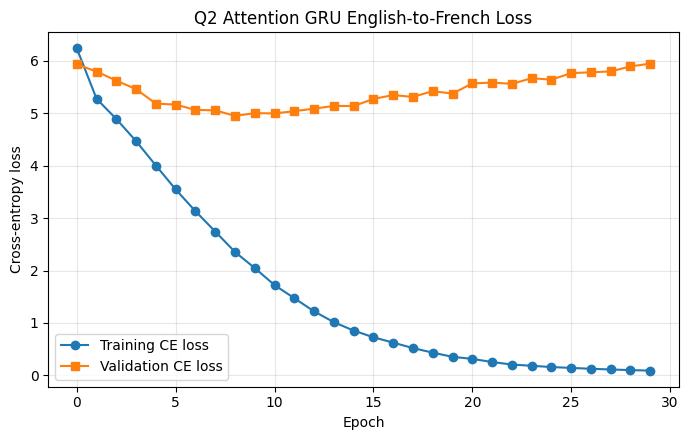

In [5]:
history = train_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    teacher_forcing_ratio=TEACHER_FORCING,
)

plot_losses(history, "Q2 Attention GRU English-to-French Loss", output_dir / "q2_attention_en_fr_loss.png")

## Validation Evaluation and Direct Comparison to Question 1

In [6]:
metrics, rows = evaluate_model(model, val_loader, src_vocab, tgt_vocab, device, max_len=30)
metrics["final_train_loss"] = history["train_loss"][-1]
metrics["final_val_loss"] = history["val_loss"][-1]
metrics["epochs"] = EPOCHS
metrics["model"] = "attention_gru_en_fr"

save_json(metrics, output_dir / "q2_attention_en_fr_metrics.json")
save_examples_csv(rows, output_dir / "q2_attention_en_fr_examples.csv")
torch.save(model.state_dict(), output_dir / "q2_attention_en_fr.pt")

q1_path = output_dir / "q1_baseline_en_fr_metrics.json"
if q1_path.exists():
    with open(q1_path, "r", encoding="utf-8") as f:
        q1_metrics = json.load(f)
    comparison = pd.DataFrame([q1_metrics, metrics])[["model", "sequence_accuracy", "bleu4", "final_val_loss"]]
else:
    comparison = pd.DataFrame([metrics])[["model", "sequence_accuracy", "bleu4", "final_val_loss"]]
    print("Run Question 1 first to populate the direct baseline comparison.")

print(json.dumps(metrics, indent=2))
comparison

{
  "sequence_accuracy": 0.009009009009009009,
  "bleu4": 0.12851292004028478,
  "n_examples": 111,
  "final_train_loss": 0.09147497479404722,
  "final_val_loss": 5.946519374847412,
  "epochs": 30,
  "model": "attention_gru_en_fr"
}


,model,sequence_accuracy,bleu4,final_val_loss
0,baseline_gru_en_fr,0.000000,0.039183,5.754569
1,attention_gru_en_fr,0.009009,0.128513,5.946519


## Attention Weight Visualizations

The maps below show which English source tokens the decoder attended to while producing French target tokens.

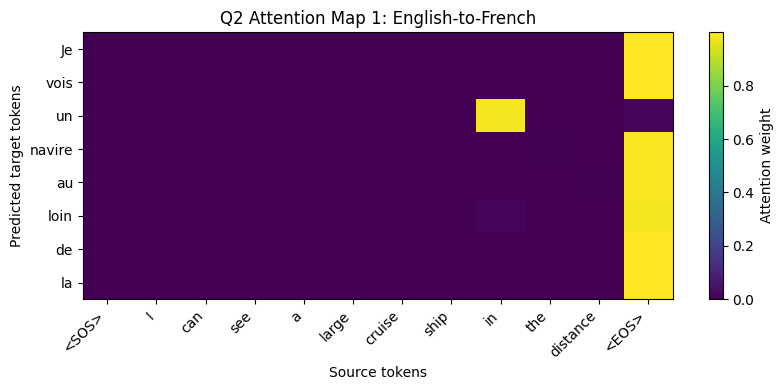

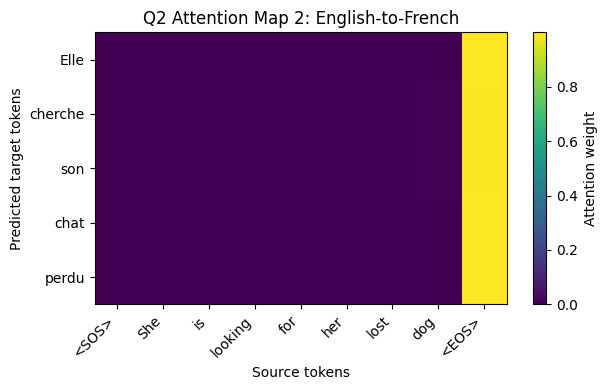

In [7]:
sample_rows = rows[:2]
for i, row in enumerate(sample_rows, start=1):
    save_attention_map(
        model,
        row["input"],
        row["target"],
        src_vocab,
        tgt_vocab,
        device,
        output_dir / f"q2_attention_map_{i}.png",
        title=f"Q2 Attention Map {i}: English-to-French",
    )

## Why BLEU Can Improve While Exact Match Stays Low

Exact-match sequence accuracy requires every generated word to match the reference sentence in the same order. One wrong article, missing accent, changed adjective form, or valid alternate phrasing makes the whole sentence count as incorrect. BLEU-4 is more graded: it rewards overlapping words and short word sequences, so a prediction can receive partial credit when it captures much of the translation even if the full sentence is not an exact match. Attention often improves local word alignment, which can raise BLEU before the model becomes consistent enough to produce many perfectly matched sentences.

## Required Qualitative Examples

In [8]:
pd.DataFrame(rows).head(5).rename(
    columns={"input": "English input", "target": "Target French", "prediction": "Predicted French"}
)

,English input,Target French,Predicted French,exact_match,bleu4
0,I can see a large cruise ship in the distance,Je peux voir un grand navire de croisière au loin,Je vois un navire au loin de la,False,0.060206
1,She is looking for her lost dog,Elle cherche son chien perdu,Elle cherche son chat perdu,False,0.285744
2,He finished his homework quickly,Il a fini ses devoirs rapidement,Il a oublié son mot de,False,0.086334
3,We prefer walking through the quiet botanical ...,Nous préférons nous promener dans les jardins ...,Nous avons regardé le lever de soleil dans les...,False,0.049394
4,They visit museums often,Ils visitent souvent des musées,Ils parlent souvent des moderne,False,0.125743
